# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Davine Olivia Agustin
- **Email:** cdcc401d6x1763@student.devacademy.id
- **ID Dicoding:** CDCC401D6X1763

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana performa proses order pada platform e-commerce?
- Pertanyaan 2 : Bagaimana performa waktu pengiriman pesanan, dan apakah terdapat keterlambatan pengiriman?
- Pertanyaan 3 : Apakah waktu pengiriman memengaruhi tingkat kepuasan pelanggan?
- Pertanyaan 4 : Kategori produk apa yang paling banyak terjual dan menghasilkan revenue terbesar?
- Pertanyaan 5 : Dari wilayah mana pelanggan paling banyak berasal, dan bagaimana distribusi order berdasarkan wilayah?

## Import Semua Packages/Library yang Digunakan

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Pada tahap ini dilakukan import berbagai library Python yang digunakan untuk mendukung proses analisis data. Library seperti pandas digunakan untuk manipulasi dan pengolahan data, numpy untuk operasi numerik, serta matplotlib dan seaborn untuk visualisasi data. Selain itu, library tambahan seperti os digunakan untuk membantu pengelolaan file dan direktori selama proses analisis berlangsung.

## Data Wrangling

### Gathering Data

In [3]:
!pip install gdown

In [4]:
!gdown 13_vwfWxZmYe4N9ZsbL2eQrp7COGZbXt8

Downloading...
From (original): https://drive.google.com/uc?id=13_vwfWxZmYe4N9ZsbL2eQrp7COGZbXt8
From (redirected): https://drive.google.com/uc?id=13_vwfWxZmYe4N9ZsbL2eQrp7COGZbXt8&confirm=t&uuid=3e9696f3-d827-46ea-b59a-317b687abb12
To: /content/E-commerce-public-dataset.zip
100% 44.9M/44.9M [00:00<00:00, 55.6MB/s]


In [5]:
!unzip E-commerce-public-dataset.zip

Archive:  E-commerce-public-dataset.zip
  inflating: E-Commerce Public Dataset/customers_dataset.csv  
  inflating: E-Commerce Public Dataset/geolocation_dataset.csv  
 extracting: E-Commerce Public Dataset/New Text Document.txt  
  inflating: E-Commerce Public Dataset/order_items_dataset.csv  
  inflating: E-Commerce Public Dataset/order_payments_dataset.csv  
  inflating: E-Commerce Public Dataset/order_reviews_dataset.csv  
  inflating: E-Commerce Public Dataset/orders_dataset.csv  
  inflating: E-Commerce Public Dataset/product_category_name_translation.csv  
  inflating: E-Commerce Public Dataset/products_dataset.csv  
  inflating: E-Commerce Public Dataset/sellers_dataset.csv  


#### Load Tabel Customers

In [6]:
import pandas as pd

df_customers = pd.read_csv("E-Commerce Public Dataset/customers_dataset.csv")
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### Load Tabel Geolocation



In [7]:
df_geolocation = pd.read_csv("E-Commerce Public Dataset/geolocation_dataset.csv")
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


#### Load Tabel Order Items

In [8]:
df_order_items = pd.read_csv("E-Commerce Public Dataset/order_items_dataset.csv")
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load Tabel Order Payments

In [9]:
df_order_payments = pd.read_csv("E-Commerce Public Dataset/order_payments_dataset.csv")
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Load Tabel Order Reviews

In [10]:
df_order_reviews = pd.read_csv("E-Commerce Public Dataset/order_reviews_dataset.csv")
df_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#### Load Tabel Orders

In [11]:
df_orders = pd.read_csv("E-Commerce Public Dataset/orders_dataset.csv")
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load Tabel Product Category Name Translation

In [12]:
df_product_category_name_translation = pd.read_csv("E-Commerce Public Dataset/product_category_name_translation.csv")
df_product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


#### Load Tabel Products

In [13]:
df_products = pd.read_csv("E-Commerce Public Dataset/products_dataset.csv")
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Load Tabel Sellers Dataset

In [14]:
df_sellers_dataset = pd.read_csv("E-Commerce Public Dataset/sellers_dataset.csv")
df_sellers_dataset.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


###**Insight**
Tahap gathering data dilakukan dengan mengumpulkan seluruh dataset yang berkaitan dengan aktivitas e-commerce, seperti:
- Data pelanggan
- Data pesanan
- Data pembayaran
- Data ulasan
- Data produk
- Data penjual
- Data lokasi geografis.

Kemudian, setiap dataset ini akan dimuat ke dalam DataFrame menggunakan pandas agar dapat dianalisis lebih lanjut.

### Assessing Data

#### Customers

In [15]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [16]:
df_customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [17]:
print("Jumlah duplikasi (seluruh baris):", df_customers.duplicated().sum())
df_customers.describe()

Jumlah duplikasi (seluruh baris): 0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


#### Geolocation

In [18]:
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [19]:
df_geolocation.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [20]:
print("Jumlah duplikasi (seluruh baris):", df_geolocation.duplicated().sum())
df_geolocation.describe()

Jumlah duplikasi (seluruh baris): 261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


#### Order Items

In [21]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [22]:
df_order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [23]:
print("Jumlah duplikasi (seluruh baris):", df_order_items.duplicated().sum())
df_order_items.describe()

Jumlah duplikasi (seluruh baris): 0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


#### Order Payments

In [24]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [25]:
df_order_payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [26]:
print("Jumlah duplikasi (seluruh baris):", df_order_payments.duplicated().sum())
df_order_payments.describe()

Jumlah duplikasi (seluruh baris): 0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


#### Order Reviews

In [27]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [28]:
df_order_reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [29]:
print("Jumlah duplikasi (seluruh baris):", df_order_reviews.duplicated().sum())
df_order_reviews.describe()

Jumlah duplikasi (seluruh baris): 0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


#### Orders

In [30]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [31]:
df_orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [32]:
print("Jumlah duplikasi (seluruh baris):", df_orders.duplicated().sum())
df_orders.describe()

Jumlah duplikasi (seluruh baris): 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


#### Product Category Name Translation

In [33]:
df_product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [34]:
df_product_category_name_translation.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [35]:
print("Jumlah duplikasi (seluruh baris):", df_product_category_name_translation.duplicated().sum())
df_product_category_name_translation.describe()

Jumlah duplikasi (seluruh baris): 0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


#### Products

In [36]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [37]:
df_products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [38]:
print("Jumlah duplikasi (seluruh baris):", df_products.duplicated().sum())
df_products.describe()

Jumlah duplikasi (seluruh baris): 0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


#### Sellers Dataset

In [39]:
df_sellers_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [40]:
df_sellers_dataset.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [41]:
print("Jumlah duplikasi (seluruh baris):", df_sellers_dataset.duplicated().sum())
df_products.describe()

Jumlah duplikasi (seluruh baris): 0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


##**Insight:**
###Data Customers:

Dataset customers memiliki kualitas data yang baik tanpa missing values maupun data duplikat. Dataset ini berisi informasi identitas pelanggan serta lokasi pelanggan seperti kota dan negara bagian.

###Data Geolocation:

Dataset geolocation tidak memiliki missing values, namun ditemukan data duplikat dalam jumlah cukup besar. Hal ini menunjukkan adanya beberapa titik lokasi yang tercatat lebih dari satu kali sehingga perlu dilakukan pembersihan data.

###Data Order Items:

Dataset order items memiliki kualitas data yang baik tanpa missing values maupun data duplikat. Dataset ini memuat informasi detail item pada setiap transaksi seperti harga produk dan biaya pengiriman.

###Data Order Payments:

Dataset order payments tidak memiliki missing values maupun data duplikat. Namun ditemukan nilai tidak wajar pada kolom payment_installments, yaitu nilai 0 yang perlu diperiksa lebih lanjut agar konsistensi data tetap terjaga.

###Data Order Reviews:

Dataset order reviews memiliki missing values pada kolom komentar ulasan seperti review_comment_title dan review_comment_message. Kondisi ini masih dapat diterima karena tidak semua pelanggan memberikan komentar tertulis ketika memberikan rating.

###Data Orders:

Dataset orders memiliki beberapa missing values pada kolom yang berkaitan dengan proses persetujuan dan pengiriman pesanan. Setelah dianalisis, missing values tersebut berkaitan dengan status order tertentu seperti canceled atau unavailable sehingga dianggap sebagai kondisi bisnis yang valid.

###Data Product Category Name Translation:

Dataset product category translation memiliki kualitas data yang baik tanpa missing values maupun duplikasi. Dataset ini digunakan untuk menerjemahkan nama kategori produk dari bahasa Portugis ke bahasa Inggris.

###Data Products:

Dataset products memiliki beberapa missing values pada atribut produk seperti kategori produk, panjang nama produk, deskripsi, berat, dan dimensi produk. Missing values ini perlu ditangani agar tidak mengganggu proses analisis maupun visualisasi data.

###Data Sellers Dataset:

Dataset sellers memiliki kualitas data yang baik tanpa missing values maupun duplikasi. Dataset ini memuat informasi seller seperti lokasi kota dan negara bagian yang nantinya dapat digunakan untuk melihat persebaran seller pada platform e-commerce.

### Cleaning Data

#### Customers

#### Geolocation

In [42]:
df_geolocation.drop_duplicates(inplace=True)
print("Jumlah duplikasi (seluruh baris):", df_geolocation.duplicated().sum())

Jumlah duplikasi (seluruh baris): 0


In [43]:
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


#### Order Items

In [44]:
datetime_columns = ["shipping_limit_date"]

for column in datetime_columns:
    df_order_items[column] = pd.to_datetime(df_order_items[column])

In [45]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### Order Payments

In [46]:
df_order_payments[df_order_payments["payment_value"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [47]:
df_order_payments[df_order_payments["payment_installments"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [48]:
df_order_payments["payment_installments"] = df_order_payments["payment_installments"].replace(0, 1)

In [49]:
df_order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853368,154.100380
std,0.706584,2.687034,217.494064
min,1.000000,1.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [50]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


####Order Reviews

In [51]:
datetime_columns = ["review_creation_date", "review_answer_timestamp"]

for column in datetime_columns:
    df_order_reviews[column] = pd.to_datetime(df_order_reviews[column])

In [52]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


####Orders

In [53]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    df_orders[column] = pd.to_datetime(df_orders[column])

In [54]:
df_orders['is_approved'] = df_orders['order_approved_at'].notna()

In [55]:
df_orders[df_orders['is_approved'] == True].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,True
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,True
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,True
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,True
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,True


In [56]:
df_orders[df_orders['is_approved'] == False].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,False
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17,False
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaT,NaT,NaT,2017-04-10,False
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaT,NaT,NaT,2018-09-13,False
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaT,NaT,NaT,2017-05-30,False
3056,ddaec6fff982b13e7e048b627a11d6da,68f4ad79cc0c2ad06e19088f5c00e9fa,canceled,2016-10-04 19:41:32,NaT,NaT,NaT,2016-11-16,False
3094,5290c34bd38a8a095b885f13958db1e1,92af427e290117f39d9ff908566072e0,canceled,2018-08-21 10:25:18,NaT,NaT,NaT,2018-09-06,False
3684,03310aa823a66056268a3bab36e827fb,25dbbf0c477fd4ae0880aaffbb12e8b3,canceled,2018-08-07 16:33:59,NaT,NaT,NaT,2018-09-04,False
4373,4c8b9947280829d0a8b7e81cc249b875,403c35c4d8813bf67b3d396b91ca1619,canceled,2018-08-09 14:54:47,NaT,NaT,NaT,2018-08-21,False
4939,b13ea375fe9c728832688264638f84cf,0dc5884bc5ffba283678229f27e07ff9,canceled,2018-08-22 18:52:29,NaT,NaT,NaT,2018-09-19,False


In [57]:
df_orders['is_shipped'] = df_orders['order_delivered_carrier_date'].notna()

In [58]:
df_orders[df_orders['is_shipped'] == True].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,True,True
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,True,True
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,True,True
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,True,True
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,True,True


In [59]:
df_orders[df_orders['is_shipped'] == False].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,True,False
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,True,False
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03,True,False
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,True,False
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09,True,False
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14,True,False
455,38b7efdf33dd5561f4f5d4f6e07b0414,021e84751ba0ead75b6d314a6ead88d9,invoiced,2017-08-01 18:17:41,2017-08-01 18:32:30,NaT,NaT,2017-08-28,True,False
586,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,True,False
687,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,True,False
737,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,True,False


In [60]:
df_orders['is_delivered'] = df_orders['order_delivered_customer_date'].notna()

In [61]:
df_orders[df_orders['is_delivered'] == True].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,True
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,True,True,True
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,True,True,True
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,True,True,True
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,True,True,True
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,True,True,True


In [62]:
df_orders[df_orders['is_shipped'] == False].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,True,False,False
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,True,False,False
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03,True,False,False
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,True,False,False
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09,True,False,False
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14,True,False,False
455,38b7efdf33dd5561f4f5d4f6e07b0414,021e84751ba0ead75b6d314a6ead88d9,invoiced,2017-08-01 18:17:41,2017-08-01 18:32:30,NaT,NaT,2017-08-28,True,False,False
586,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,True,False,False
687,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,True,False,False
737,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,True,False,False


In [63]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   is_approved                    99441 non-null  bool          
 9   is_shipped                     99441 non-null  bool          
 10  is_delivered                   99441 non-null  bool          
dtypes: bool(3), dat

####Product Category Name Translation

####Products

In [64]:
df_products.product_category_name.value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


In [217]:
df_products.product_category_name.fillna(value="cama_mesa_banho", inplace=True)

/tmp/ipykernel_7027/2560333135.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_category_name.fillna(value="cama_mesa_banho", inplace=True)


In [66]:
df_products.product_name_lenght.value_counts()

,count
product_name_lenght,
60.0,2182
59.0,2025
58.0,1887
57.0,1719
55.0,1683
...,...
66.0,1
72.0,1
67.0,1


In [67]:
df_products.product_name_lenght.fillna(value="60.0", inplace=True)

/tmp/ipykernel_7027/2181233157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_name_lenght.fillna(value="60.0", inplace=True)
/tmp/ipykernel_7027/2181233157.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '60.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_products.product_name_lenght.fillna(value="60.0", inplace=True)


In [68]:
df_products.product_description_lenght.value_counts()

,count
product_description_lenght,
404.0,94
729.0,86
651.0,66
703.0,66
236.0,65
...,...
1615.0,1
3323.0,1
2308.0,1


In [69]:
df_products.product_description_lenght.fillna(value="404.0", inplace=True)

/tmp/ipykernel_7027/2980582757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_description_lenght.fillna(value="404.0", inplace=True)
/tmp/ipykernel_7027/2980582757.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '404.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_products.product_description_lenght.fillna(value="404.0", inplace=True)


In [70]:
df_products.product_photos_qty.value_counts()

,count
product_photos_qty,
1.0,16489
2.0,6263
3.0,3860
4.0,2428
5.0,1484
6.0,968
7.0,343
8.0,192
9.0,105


In [71]:
df_products.product_photos_qty.fillna(value="1.0", inplace=True)

/tmp/ipykernel_7027/1535235789.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_photos_qty.fillna(value="1.0", inplace=True)
/tmp/ipykernel_7027/1535235789.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_products.product_photos_qty.fillna(value="1.0", inplace=True)


In [72]:
df_products.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [73]:
df_products.product_weight_g.value_counts()

,count
product_weight_g,
200.0,2084
300.0,1561
150.0,1259
400.0,1206
100.0,1188
...,...
4497.0,1
3040.0,1
908.0,1


In [74]:
df_products.product_weight_g.fillna(value="200.0", inplace=True)

/tmp/ipykernel_7027/2185219728.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_weight_g.fillna(value="200.0", inplace=True)
/tmp/ipykernel_7027/2185219728.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '200.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_products.product_weight_g.fillna(value="200.0", inplace=True)


In [75]:
df_products.product_length_cm.value_counts()

,count
product_length_cm,
16.0,5520
20.0,2816
30.0,2029
18.0,1502
25.0,1387
...,...
96.0,4
10.0,3
8.0,2


In [219]:
df_products.product_length_cm.fillna(value="16.0", inplace=True)

/tmp/ipykernel_7027/4161086624.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_length_cm.fillna(value="16.0", inplace=True)


In [77]:
df_products.product_height_cm.value_counts()

,count
product_height_cm,
10.0,2548
15.0,2022
20.0,1991
16.0,1595
11.0,1551
...,...
98.0,2
97.0,2
99.0,1


In [78]:
df_products.product_height_cm.fillna(value="10.0", inplace=True)

/tmp/ipykernel_7027/4007287828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_height_cm.fillna(value="10.0", inplace=True)
/tmp/ipykernel_7027/4007287828.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_products.product_height_cm.fillna(value="10.0", inplace=True)


In [79]:
df_products.product_width_cm.value_counts()

,count
product_width_cm,
11.0,3718
20.0,3053
16.0,2808
15.0,2393
30.0,1786
...,...
103.0,1
118.0,1
97.0,1


In [80]:
df_products.product_width_cm.fillna(value="11.0", inplace=True)

/tmp/ipykernel_7027/256330269.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products.product_width_cm.fillna(value="11.0", inplace=True)
/tmp/ipykernel_7027/256330269.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_products.product_width_cm.fillna(value="11.0", inplace=True)


In [81]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   product_id                  32951 non-null  object
 1   product_category_name       32951 non-null  object
 2   product_name_lenght         32951 non-null  object
 3   product_description_lenght  32951 non-null  object
 4   product_photos_qty          32951 non-null  object
 5   product_weight_g            32951 non-null  object
 6   product_length_cm           32951 non-null  object
 7   product_height_cm           32951 non-null  object
 8   product_width_cm            32951 non-null  object
dtypes: object(9)
memory usage: 2.3+ MB


In [82]:
df_products.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


####Sellers Dataset

##**Insight**

###Data Customers, Product Category Name Translation, Sellers Dataset:

Dataset ini tidak memerlukan proses cleaning tambahan karena tidak ditemukan missing values maupun data duplikat.

###Data Geolocation:

Proses cleaning pada dataset geolocation dilakukan dengan menghapus data duplikat untuk mengurangi redundansi data lokasi dan meningkatkan kualitas analisis geografis.

###Data Order Items:

Kolom bertipe tanggal pada dataset order items dikonversi ke format datetime agar dapat digunakan untuk analisis waktu dan proses pengiriman secara lebih akurat.

###Data Order Payments:

Nilai payment_installments yang bernilai 0 diperbaiki menjadi 1 untuk menjaga konsistensi data pembayaran karena minimal pembayaran dilakukan sebanyak satu kali.

###Data Order Reviews:

Kolom tanggal pada dataset order reviews dikonversi menjadi tipe data datetime agar mempermudah proses analisis waktu pemberian ulasan pelanggan.

###Data Orders:

Kolom bertipe tanggal pada dataset orders dikonversi ke format datetime untuk mempermudah analisis proses transaksi dan pengiriman. Selain itu, dilakukan penyesuaian terhadap missing values berdasarkan konteks status pesanan.

###Data Products:

Proses cleaning pada dataset products dilakukan dengan menangani missing values pada beberapa atribut produk menggunakan teknik imputasi yang sesuai. Langkah ini bertujuan untuk menjaga konsistensi data serta memastikan dataset tetap dapat digunakan dalam proses analisis.


## Exploratory Data Analysis (EDA)

###Explore Customers

In [83]:
df_customers.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [84]:
df_customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [85]:
df_customers.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [86]:
df_customers['customer_unique_id'].nunique()

96096

In [87]:
customer_by_state = df_customers.groupby(by="customer_state").customer_unique_id.nunique().sort_values(ascending=False)

customer_by_state

,customer_unique_id
customer_state,
SP,40302
RJ,12384
MG,11259
RS,5277
PR,4882
SC,3534
BA,3277
DF,2075
ES,1964


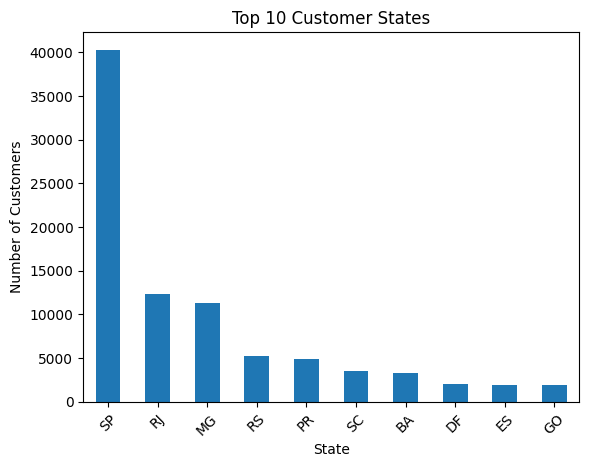

In [88]:
import matplotlib.pyplot as plt

customer_by_state.head(10).plot(kind='bar')

plt.title('Top 10 Customer States')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [89]:
customer_by_city = df_customers.groupby(by="customer_city").customer_unique_id.nunique().sort_values(ascending=False)

customer_by_city.head(10)

,customer_unique_id
customer_city,
sao paulo,14984
rio de janeiro,6620
belo horizonte,2672
brasilia,2069
curitiba,1465
campinas,1398
porto alegre,1326
salvador,1209
guarulhos,1153


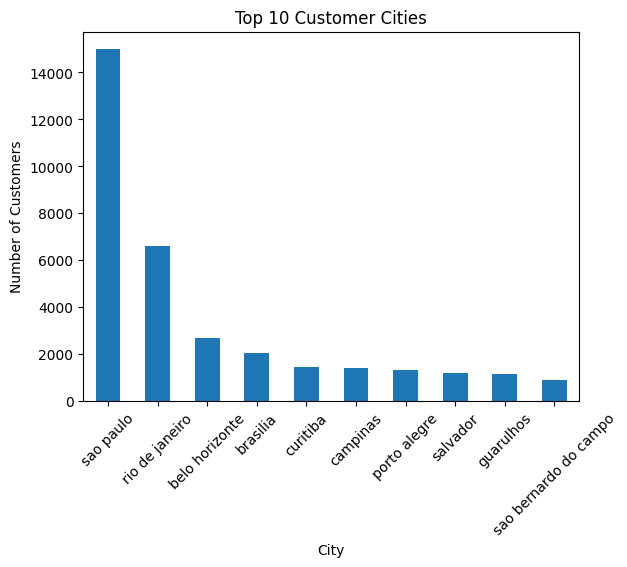

In [90]:
customer_by_city.head(10).plot(kind='bar')

plt.title('Top 10 Customer Cities')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [91]:
print("Total customer_id:", df_customers['customer_id'].nunique())
print("Total customer_unique_id:", df_customers['customer_unique_id'].nunique())

Total customer_id: 99441
Total customer_unique_id: 96096


In [92]:
df_customers['customer_state'].value_counts(normalize=True) * 100

,proportion
customer_state,
SP,41.980672
RJ,12.924247
MG,11.700405
RS,5.496727
PR,5.073360
SC,3.657445
BA,3.399000
DF,2.152030
ES,2.044428


###Explore Geolocation

In [93]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [94]:
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


In [95]:
df_geolocation.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,738332.000000,738332.000000,738332.000000,738332,738332
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,79927,285976
mean,38316.086800,-20.998353,-46.461098,NaN,NaN
std,30632.496675,5.892315,4.393705,NaN,NaN
min,1001.000000,-36.605374,-101.466766,NaN,NaN
25%,12600.000000,-23.603061,-48.867822,NaN,NaN
50%,29144.000000,-22.873588,-46.647278,NaN,NaN
75%,65950.000000,-19.923336,-43.836974,NaN,NaN


In [96]:
df_geolocation['geolocation_state'].nunique()

27

In [97]:
geo_by_state = df_geolocation.groupby(by="geolocation_state").size().sort_values(ascending=False)

geo_by_state

,0
geolocation_state,
SP,285976
MG,101353
RJ,78836
RS,48093
PR,45059
SC,30191
BA,27720
GO,15601
PE,13162


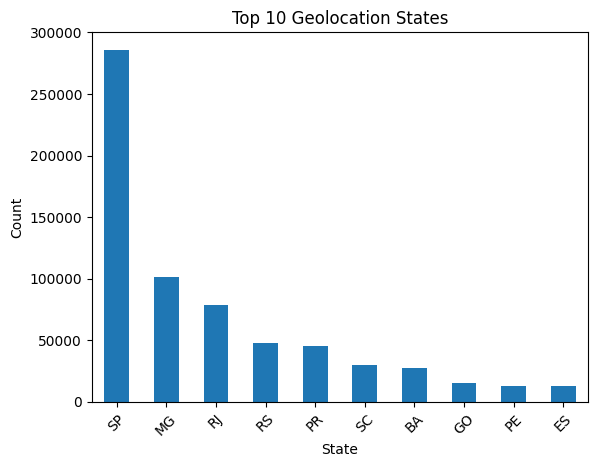

In [98]:
import matplotlib.pyplot as plt

geo_by_state.head(10).plot(kind='bar')

plt.title('Top 10 Geolocation States')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [99]:
geo_by_city = df_geolocation.groupby(by="geolocation_city").size().sort_values(ascending=False)

geo_by_city.head(10)

,0
geolocation_city,
sao paulo,79927
rio de janeiro,35177
são paulo,19718
belo horizonte,19474
curitiba,11263
porto alegre,8702
salvador,8083
guarulhos,7411
brasilia,6919


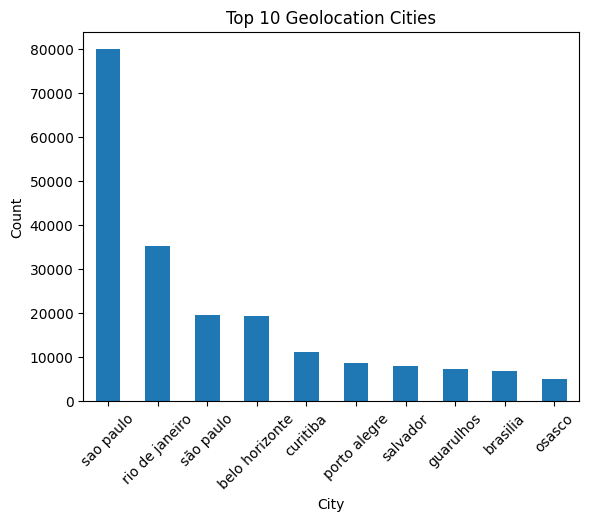

In [100]:
geo_by_city.head(10).plot(kind='bar')

plt.title('Top 10 Geolocation Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [101]:
df_geolocation[['geolocation_lat', 'geolocation_lng']].describe()

,geolocation_lat,geolocation_lng
count,738332.000000,738332.000000
mean,-20.998353,-46.461098
std,5.892315,4.393705
min,-36.605374,-101.466766
25%,-23.603061,-48.867822
50%,-22.873588,-46.647278
75%,-19.923336,-43.836974
max,45.065933,121.105394


###Explore Order Items

In [102]:
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [103]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [104]:
df_order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN
freq,21,NaN,527,2033,NaN,NaN,NaN
mean,NaN,1.197834,NaN,NaN,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,2018-01-26 13:59:35,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000


In [105]:
df_order_items['product_id'].nunique()

32951

In [106]:
df_order_items['seller_id'].nunique()

3095

In [107]:
df_order_items['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


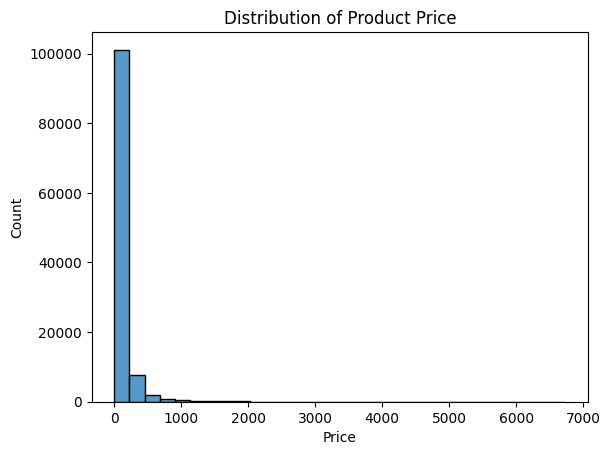

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_order_items['price'], bins=30)

plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.show()

In [109]:
df_order_items['freight_value'].describe()

,freight_value
count,112650.000000
mean,19.990320
std,15.806405
min,0.000000
25%,13.080000
50%,16.260000
75%,21.150000
max,409.680000


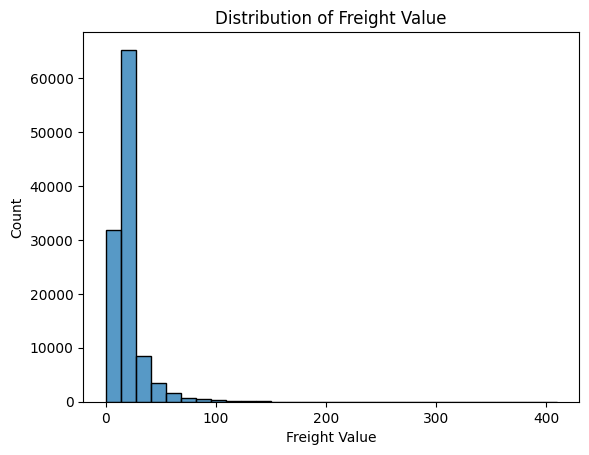

In [110]:
sns.histplot(df_order_items['freight_value'], bins=30)

plt.title('Distribution of Freight Value')
plt.xlabel('Freight Value')
plt.show()

In [111]:
items_per_order = df_order_items.groupby(by='order_id').size()

items_per_order.describe()

,0
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


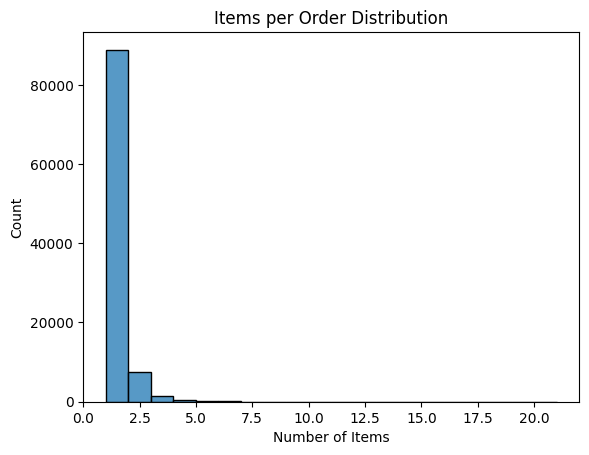

In [112]:
sns.histplot(items_per_order, bins=20)

plt.title('Items per Order Distribution')
plt.xlabel('Number of Items')
plt.show()

###Explore Order Payments

In [113]:
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [114]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [115]:
df_order_payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853368,154.100380
std,NaN,0.706584,NaN,2.687034,217.494064
min,NaN,1.000000,NaN,1.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [116]:
payment_type = df_order_payments['payment_type'].value_counts()

payment_type

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


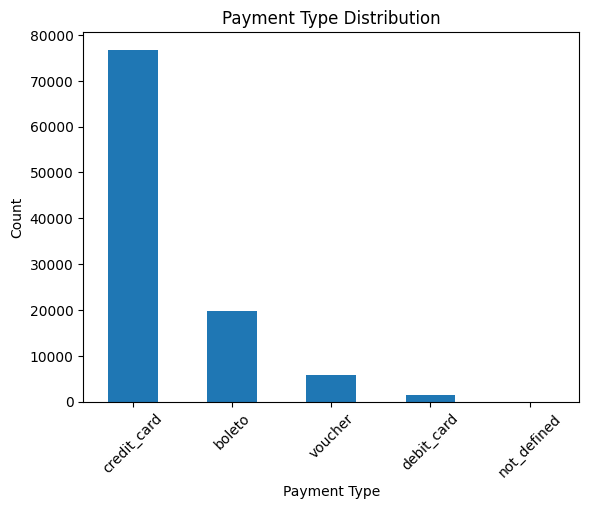

In [117]:
import matplotlib.pyplot as plt

payment_type.plot(kind='bar')

plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [118]:
df_order_payments['payment_value'].describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


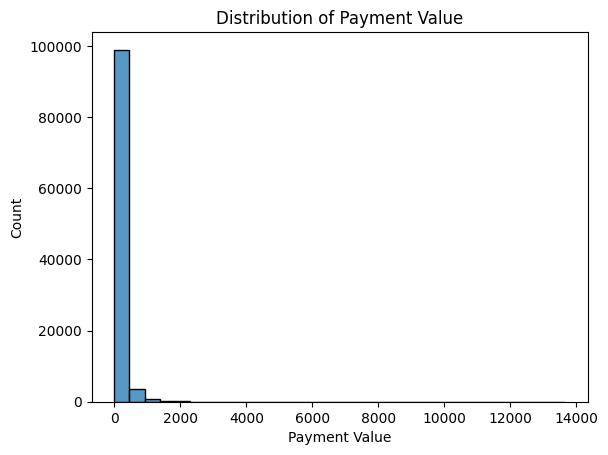

In [119]:
import seaborn as sns

sns.histplot(df_order_payments['payment_value'], bins=30)

plt.title('Distribution of Payment Value')
plt.xlabel('Payment Value')
plt.show()

In [120]:
installments = df_order_payments['payment_installments'].value_counts().sort_index()

installments

,count
payment_installments,
1,52548
2,12413
3,10461
4,7098
5,5239
6,3920
7,1626
8,4268
9,644


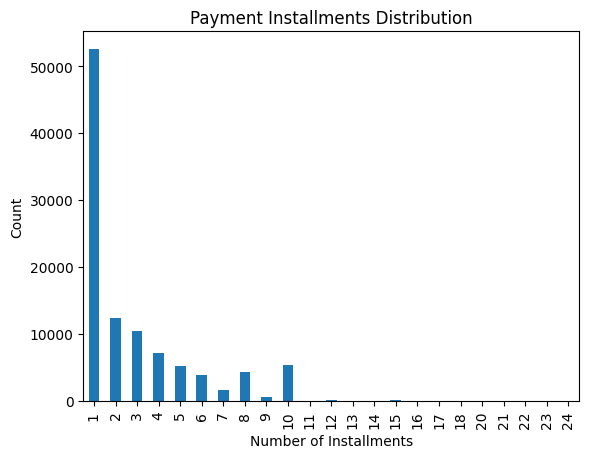

In [121]:
installments.plot(kind='bar')

plt.title('Payment Installments Distribution')
plt.xlabel('Number of Installments')
plt.ylabel('Count')
plt.show()

In [122]:
df_order_payments.groupby(by='payment_type')['payment_value'].mean().sort_values(ascending=False)

,payment_value
payment_type,
credit_card,163.319021
boleto,145.034435
debit_card,142.570170
voucher,65.703354
not_defined,0.000000


###Explore Order Reviews

In [123]:
df_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [124]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [125]:
df_order_reviews.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,NaN,NaN
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,Recomendo,Muito bom,NaN,NaN
freq,3,3,NaN,423,230,NaN,NaN
mean,NaN,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688
min,NaN,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,NaN,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872
50%,NaN,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,NaN,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,NaN,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35


In [126]:
review_score = df_order_reviews['review_score'].value_counts().sort_index()

review_score

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


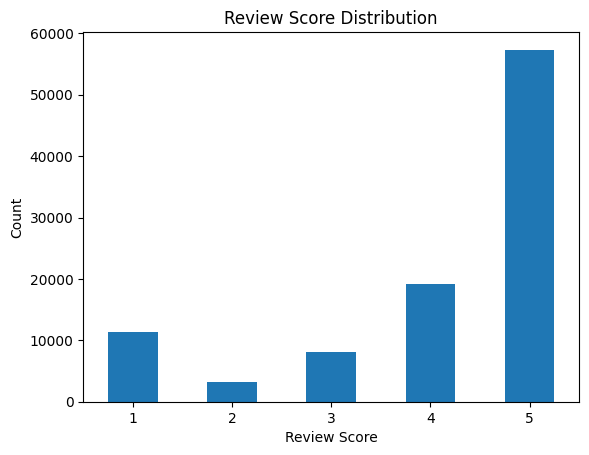

In [127]:
import matplotlib.pyplot as plt

review_score.plot(kind='bar')

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [128]:
df_order_reviews[['review_comment_title', 'review_comment_message']].isna().sum()

,0
review_comment_title,87656
review_comment_message,58247


In [129]:
df_order_reviews['review_score'].mean()

np.float64(4.08642062404257)

In [130]:
df_order_reviews[['review_creation_date', 'review_answer_timestamp']].head()

,review_creation_date,review_answer_timestamp
0,2018-01-18,2018-01-18 21:46:59
1,2018-03-10,2018-03-11 03:05:13
2,2018-02-17,2018-02-18 14:36:24
3,2017-04-21,2017-04-21 22:02:06
4,2018-03-01,2018-03-02 10:26:53


In [131]:
def review_category(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df_order_reviews['review_category'] = df_order_reviews['review_score'].apply(review_category)

In [132]:
df_order_reviews['review_category'].value_counts()

,count
review_category,
Positive,76470
Negative,14575
Neutral,8179


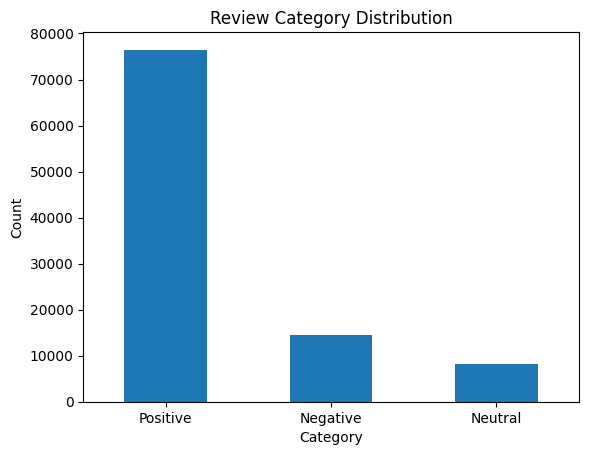

In [133]:
df_order_reviews['review_category'].value_counts().plot(kind='bar')

plt.title('Review Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

###Explore Orders

In [134]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,True


In [135]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   is_approved                    99441 non-null  bool          
 9   is_shipped                     99441 non-null  bool          
 10  is_delivered                   99441 non-null  bool          
dtypes: bool(3), dat

In [136]:
df_orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered
count,99441,99441,99441,99441,99281,97658,96476,99441,99441,99441,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,2,2,2
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,True,True,True
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,99281,97658,96476
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,NaN,NaN,NaN
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,NaN,NaN,NaN


In [137]:
order_status = df_orders['order_status'].value_counts()

order_status

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


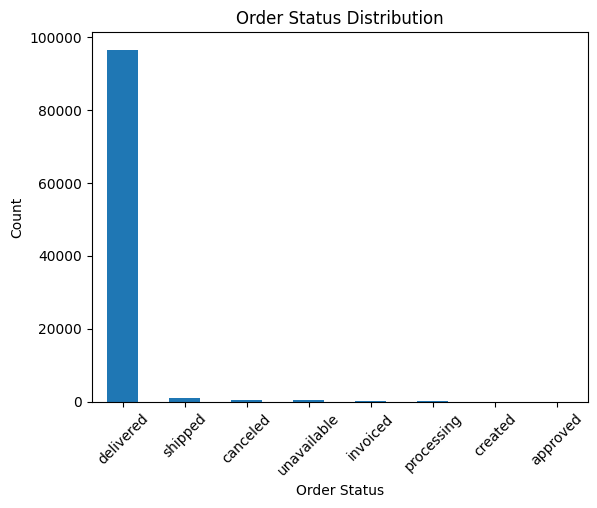

In [138]:
import matplotlib.pyplot as plt

order_status.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [139]:
funnel = {
    'Approved': df_orders['is_approved'].sum(),
    'Shipped': df_orders['is_shipped'].sum(),
    'Delivered': df_orders['is_delivered'].sum()
}

funnel

{'Approved': np.int64(99281),
 'Shipped': np.int64(97658),
 'Delivered': np.int64(96476)}

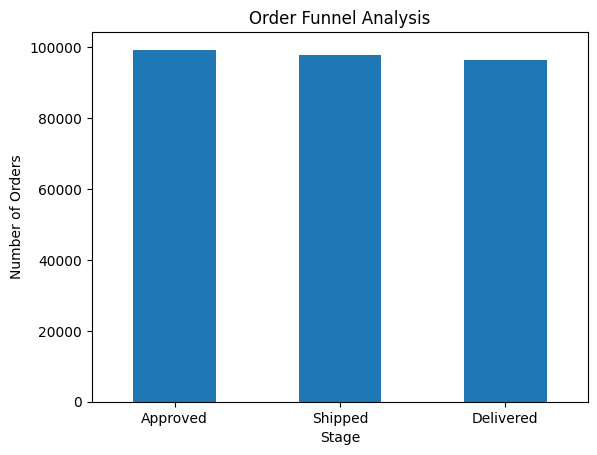

In [140]:
import pandas as pd

funnel_df = pd.DataFrame({
    'Stage': funnel.keys(),
    'Orders': funnel.values()
})

funnel_df.plot(x='Stage', y='Orders', kind='bar', legend=False)

plt.title('Order Funnel Analysis')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

In [141]:
total_orders = len(df_orders)

approved_rate = (df_orders['is_approved'].sum() / total_orders) * 100
shipped_rate = (df_orders['is_shipped'].sum() / total_orders) * 100
delivered_rate = (df_orders['is_delivered'].sum() / total_orders) * 100

print(f"Approved Rate: {approved_rate:.2f}%")
print(f"Shipped Rate: {shipped_rate:.2f}%")
print(f"Delivered Rate: {delivered_rate:.2f}%")

Approved Rate: 99.84%
Shipped Rate: 98.21%
Delivered Rate: 97.02%


In [142]:
df_orders['delivery_time'] = (
    df_orders['order_delivered_customer_date']
    - df_orders['order_purchase_timestamp']
).dt.days

In [143]:
df_orders['delivery_time'].describe()

,delivery_time
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


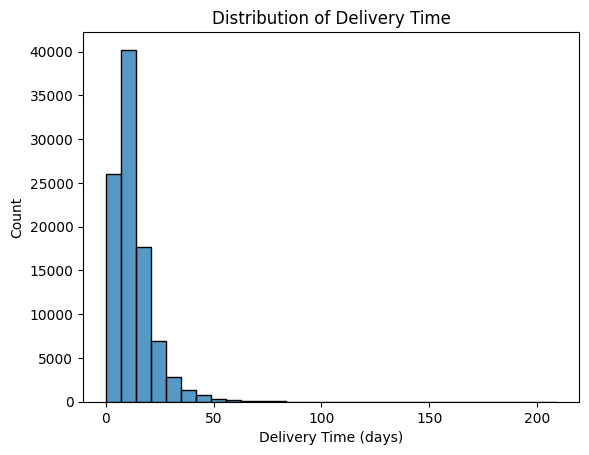

In [144]:
import seaborn as sns

sns.histplot(df_orders['delivery_time'].dropna(), bins=30)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (days)')
plt.show()

In [145]:
df_orders['delivery_delay'] = (
    df_orders['order_delivered_customer_date']
    - df_orders['order_estimated_delivery_date']
).dt.days

In [146]:
df_orders['delivery_delay'].describe()

,delivery_delay
count,96476.000000
mean,-11.876881
std,10.183854
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


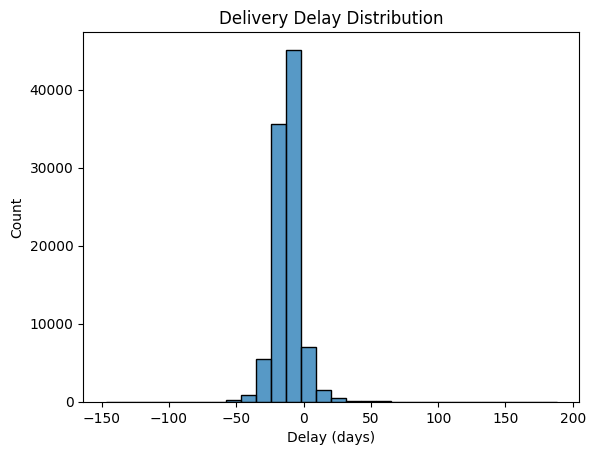

In [147]:
sns.histplot(df_orders['delivery_delay'].dropna(), bins=30)

plt.title('Delivery Delay Distribution')
plt.xlabel('Delay (days)')
plt.show()

###Explore Product Category Name Translation

In [148]:
df_product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [149]:
df_product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [150]:
df_product_category_name_translation.describe(include='all')

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [151]:
df_product_category_name_translation['product_category_name'].nunique()

71

In [152]:
df_product_category_name_translation.sample(10)

,product_category_name,product_category_name_english
48,livros_interesse_geral,books_general_interest
9,relogios_presentes,watches_gifts
14,brinquedos,toys
70,seguros_e_servicos,security_and_services
49,construcao_ferramentas_seguranca,construction_tools_safety
64,cds_dvds_musicais,cds_dvds_musicals
30,moveis_escritorio,office_furniture
56,eletrodomesticos_2,home_appliances_2
2,automotivo,auto
31,market_place,market_place


In [153]:
df_product_category_name_translation.isna().sum()

,0
product_category_name,0
product_category_name_english,0


###Explore Products

In [154]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [155]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   product_id                  32951 non-null  object
 1   product_category_name       32951 non-null  object
 2   product_name_lenght         32951 non-null  object
 3   product_description_lenght  32951 non-null  object
 4   product_photos_qty          32951 non-null  object
 5   product_weight_g            32951 non-null  object
 6   product_length_cm           32951 non-null  object
 7   product_height_cm           32951 non-null  object
 8   product_width_cm            32951 non-null  object
dtypes: object(9)
memory usage: 2.3+ MB


In [156]:
df_products.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32951,32951.0,32951,32951.0,32951.0,32951.0,32951.0,32951.0
unique,32951,73,67.0,2961,20.0,2205.0,100.0,103.0,96.0
top,106392145fca363410d287a815be6de4,cama_mesa_banho,60.0,404.0,1.0,200.0,16.0,10.0,11.0
freq,1,3639,2182.0,610,16489.0,2084.0,5520.0,2548.0,3718.0


In [157]:
df_products['product_id'].nunique()

32951

In [158]:
product_category = df_products['product_category_name'].value_counts()

product_category.head(10)

,count
product_category_name,
cama_mesa_banho,3639
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


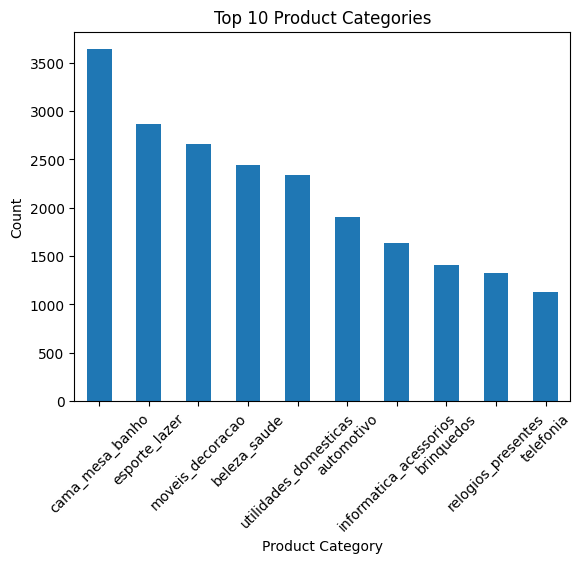

In [159]:
import matplotlib.pyplot as plt

product_category.head(10).plot(kind='bar')

plt.title('Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [160]:
df_products[[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.0,32951.0,32951.0,32951.0
unique,2205.0,100.0,103.0,96.0
top,200.0,16.0,10.0,11.0
freq,2084.0,5520.0,2548.0,3718.0


In [161]:
df_products[[
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty'
]].describe()

,product_name_lenght,product_description_lenght,product_photos_qty
count,32951.0,32951,32951.0
unique,67.0,2961,20.0
top,60.0,404.0,1.0
freq,2182.0,610,16489.0


In [162]:
df_products['product_photos_qty'] = pd.to_numeric(
    df_products['product_photos_qty'],
    errors='coerce'
)

In [163]:
photo_distribution = df_products['product_photos_qty'].value_counts().sort_index()

photo_distribution.head(15)

,count
product_photos_qty,
1.0,17099
2.0,6263
3.0,3860
4.0,2428
5.0,1484
6.0,968
7.0,343
8.0,192
9.0,105


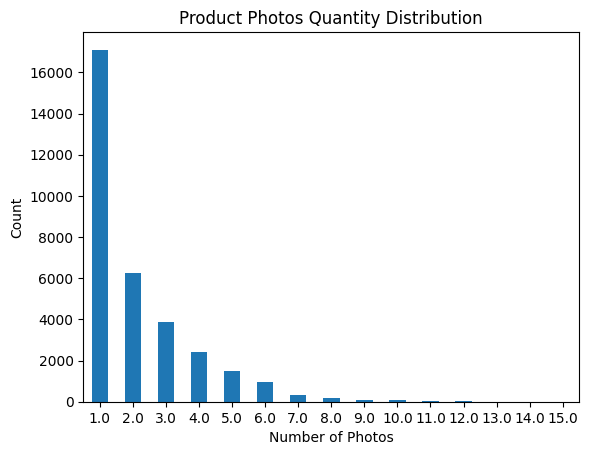

In [164]:
photo_distribution.head(15).plot(kind='bar')

plt.title('Product Photos Quantity Distribution')
plt.xlabel('Number of Photos')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [165]:
df_products.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


###Explore Sellers Dataset

In [166]:
df_sellers_dataset.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [167]:
df_sellers_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [168]:
df_sellers_dataset.describe(include='all')

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [169]:
df_sellers_dataset['seller_id'].nunique()

3095

In [170]:
seller_by_state = df_sellers_dataset.groupby(
    by='seller_state'
).seller_id.nunique().sort_values(ascending=False)

seller_by_state

,seller_id
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


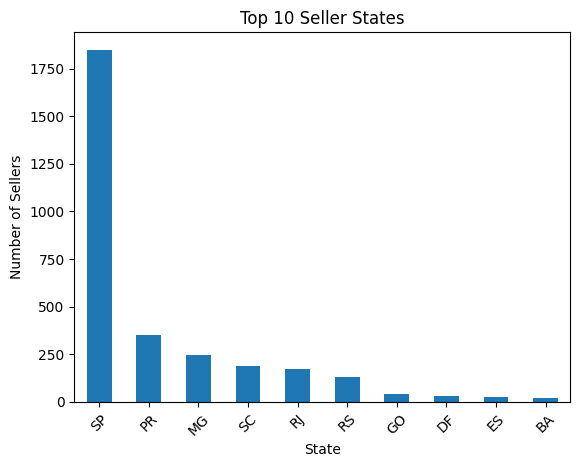

In [171]:
import matplotlib.pyplot as plt

seller_by_state.head(10).plot(kind='bar')

plt.title('Top 10 Seller States')
plt.xlabel('State')
plt.ylabel('Number of Sellers')
plt.xticks(rotation=45)
plt.show()

In [172]:
seller_by_city = df_sellers_dataset.groupby(
    by='seller_city'
).seller_id.nunique().sort_values(ascending=False)

seller_by_city.head(10)

,seller_id
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
guarulhos,50
ibitinga,49
santo andre,45
campinas,41


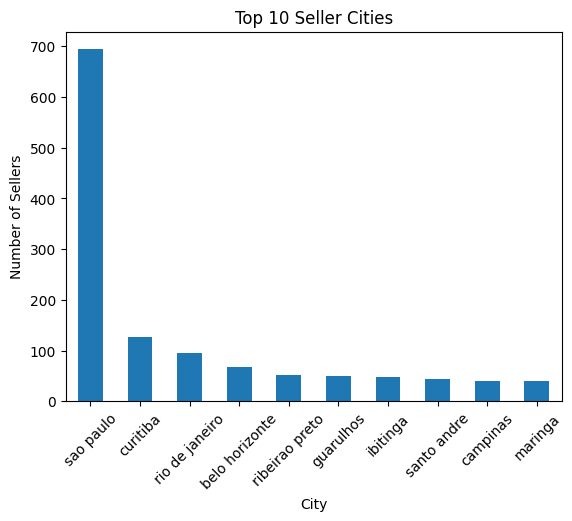

In [173]:
seller_by_city.head(10).plot(kind='bar')

plt.title('Top 10 Seller Cities')
plt.xlabel('City')
plt.ylabel('Number of Sellers')
plt.xticks(rotation=45)
plt.show()

In [174]:
df_sellers_dataset['seller_zip_code_prefix'].describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [175]:
df_orders_customers = pd.merge(
    df_orders,
    df_customers,
    on='customer_id',
    how='left'
)

df_orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,True,8.0,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,True,13.0,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,True,9.0,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,True,13.0,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,True,2.0,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [176]:
df_orders_customers_items = pd.merge(
    df_orders_customers,
    df_order_items,
    on='order_id',
    how='left'
)

df_orders_customers_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [177]:
df_orders_customers_items_products = pd.merge(
    df_orders_customers_items,
    df_products,
    on='product_id',
    how='left'
)

df_orders_customers_items_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [178]:
df_orders_customers_items_products_translation = pd.merge(
    df_orders_customers_items_products,
    df_product_category_name_translation,
    on='product_category_name',
    how='left'
)

df_orders_customers_items_products_translation.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,True,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,True,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [179]:
df_all = pd.merge(
    df_orders_customers_items_products_translation,
    df_order_reviews,
    on='order_id',
    how='left'
)

In [180]:
df_all = pd.merge(
    df_all,
    df_order_payments,
    on='order_id',
    how='left'
)

In [181]:
df_all.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_category,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Positive,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Positive,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,True,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Positive,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,True,...,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,Positive,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,True,...,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,Positive,1.0,credit_card,3.0,179.12


In [182]:
df_all.groupby(
    by=['customer_state', 'product_category_name_english']
).agg({
    'order_item_id': 'count',
    'price': 'sum'
}).sort_values(by='price', ascending=False)

order_item_id      price
customer_state product_category_name_english                          
SP             bed_bath_table                          6377  583288.08
               health_beauty                           4348  475928.29
               watches_gifts                           2354  450822.51
               sports_leisure                          3831  403732.12
               computers_accessories                   3267  360210.34
...                                                     ...        ...
AL             drinks                                     1      15.49
BA             home_comfort_2                             1      12.90
ES             home_comfort_2                             1      12.90
PR             home_comfort_2                             1      12.90
MS             costruction_tools_tools                    1       6.80

[1356 rows x 2 columns]

In [183]:
df_all.groupby(
    by=['review_score', 'product_category_name_english']
).agg({
    'order_item_id': 'count',
    'price': 'sum'
}).sort_values(by='order_item_id', ascending=False)

order_item_id      price
review_score product_category_name_english                          
5.0          bed_bath_table                          7048  673141.50
             health_beauty                           6024  802303.46
             sports_leisure                          5284  594978.93
             furniture_decor                         4698  410484.38
             computers_accessories                   4347  503965.70
...                                                   ...        ...
2.0          fashion_sport                              1      64.99
4.0          security_and_services                      1     183.29
2.0          books_imported                             1     135.00
             dvds_blu_ray                               1      83.99
1.0          fashion_childrens_clothes                  1      49.90

[340 rows x 2 columns]

In [184]:
df_all.groupby(
    by=['payment_type', 'product_category_name_english']
).agg({
    'payment_value': 'sum'
}).sort_values(by='payment_value', ascending=False)

payment_value
payment_type product_category_name_english                       
credit_card  bed_bath_table                            1597218.08
             health_beauty                             1330785.44
             watches_gifts                             1170548.59
             sports_leisure                            1093287.80
             furniture_decor                           1088757.60
...                                                           ...
debit_card   costruction_tools_garden                       53.30
voucher      cine_photo                                     44.12
             home_comfort_2                                 37.90
debit_card   small_appliances_home_oven_and_coffee          35.65
voucher      christmas_supplies                             35.50

[263 rows x 1 columns]

In [185]:
df_all.groupby(
    by='customer_state'
).agg({
    'delivery_time': 'mean',
    'delivery_delay': 'mean'
}).sort_values(by='delivery_delay', ascending=False)

,delivery_time,delivery_delay
customer_state,,
AL,24.128090,-8.543820
MA,21.191981,-9.964763
SE,20.886010,-10.025907
ES,15.235116,-10.603538
BA,18.734684,-10.987848
SP,8.274160,-11.233759
MS,15.057783,-11.250000
CE,20.344415,-11.311835
PI,18.893502,-11.465704


In [186]:
df_all.groupby(
    by='review_score'
).agg({
    'delivery_delay': 'mean',
    'delivery_time': 'mean'
})

,delivery_delay,delivery_time
review_score,,
1.0,-5.993827,19.099992
2.0,-9.748141,15.381893
3.0,-11.114301,13.552435
4.0,-12.468533,11.778330
5.0,-13.443437,10.203253


In [187]:
df_all.groupby(
    by='customer_state'
).agg({
    'payment_value': 'sum'
}).sort_values(by='payment_value', ascending=False)

,payment_value
customer_state,
SP,7726078.35
RJ,2795615.67
MG,2351221.09
RS,1160175.66
PR,1079795.49
BA,805070.98
SC,801276.45
GO,520481.65
DF,438095.32


##**Insight**

###Data Customers:

Analisis pada dataset customers menunjukkan bahwa pelanggan tersebar di berbagai kota dan negara bagian di Brazil. Beberapa wilayah memiliki jumlah pelanggan yang lebih dominan dibandingkan wilayah lainnya sehingga menunjukkan pusat aktivitas pelanggan berada pada area tertentu.

###Data Geolocation:

Analisis geolocation menunjukkan persebaran lokasi pelanggan dan seller yang cukup luas. Beberapa kota memiliki jumlah titik lokasi paling banyak yang mengindikasikan tingginya aktivitas transaksi e-commerce pada wilayah tersebut.

###Data Order Items:

Sebagian besar transaksi terdiri dari satu hingga beberapa item produk saja. Selain itu, distribusi harga produk dan biaya pengiriman menunjukkan adanya variasi nilai transaksi dari harga rendah hingga tinggi.

###Data Order Payments:

Metode pembayaran yang paling sering digunakan pelanggan adalah credit card. Selain itu, mayoritas pelanggan menggunakan jumlah cicilan dalam skala kecil sehingga menunjukkan preferensi terhadap pembayaran dengan tenor pendek.

###Data Order Reviews:

Sebagian besar pelanggan memberikan review dengan skor tinggi, terutama pada skor 5, yang menunjukkan tingkat kepuasan pelanggan cukup baik terhadap layanan e-commerce. Namun masih terdapat sebagian kecil review rendah yang dapat menjadi indikator adanya kendala pada layanan atau pengiriman.

###Data Orders:

Mayoritas pesanan berhasil diselesaikan dengan status delivered yang menunjukkan proses transaksi dan pengiriman berjalan dengan baik. Selain itu, terdapat fluktuasi jumlah pesanan pada periode tertentu yang menunjukkan perubahan aktivitas pembelian pelanggan dari waktu ke waktu.

###Data Product Category Name Translation:

Dataset translasi kategori produk membantu mempermudah proses identifikasi kategori produk dalam bahasa Inggris sehingga analisis kategori produk menjadi lebih mudah dipahami.

###Data Products:

Beberapa kategori produk memiliki jumlah produk yang jauh lebih banyak dibandingkan kategori lainnya. Selain itu, sebagian besar produk hanya memiliki sedikit foto produk yang dapat memengaruhi daya tarik produk pada platform e-commerce.

###Data Sellers Dataset:

Seller pada platform e-commerce tersebar di berbagai wilayah di Brazil, namun terdapat konsentrasi seller yang lebih tinggi pada beberapa negara bagian tertentu. Hal ini menunjukkan pusat aktivitas penjualan masih terfokus pada area tertentu.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa proses order pada platform e-commerce?

In [188]:
monthly_orders_df = df_orders.resample(
    rule='M',
    on='order_purchase_timestamp'
).agg({
    "order_id": "nunique"
})

monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')

monthly_orders_df = monthly_orders_df.reset_index()

monthly_orders_df.rename(columns={
    "order_id": "order_count"
}, inplace=True)

monthly_orders_df.head()

/tmp/ipykernel_7027/853693980.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = df_orders.resample(


,order_purchase_timestamp,order_count
0,2016-09,4
1,2016-10,324
2,2016-11,0
3,2016-12,1
4,2017-01,800


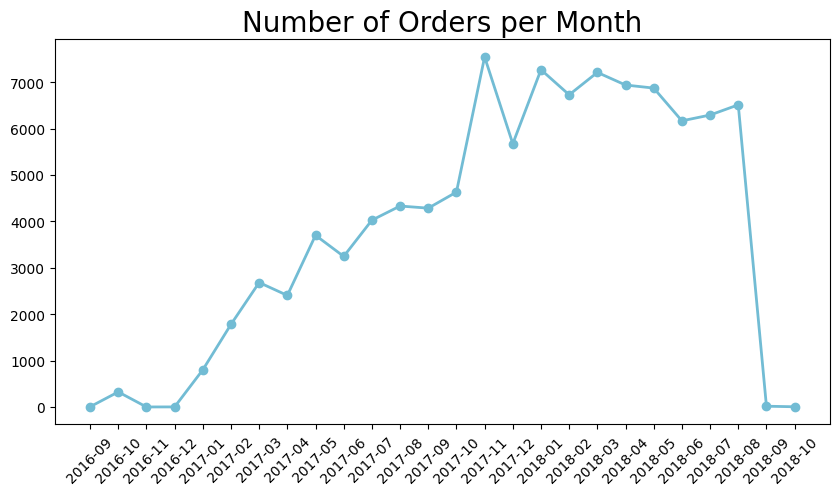

In [189]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders_df["order_purchase_timestamp"],
    monthly_orders_df["order_count"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Number of Orders per Month", loc="center", fontsize=20)

plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

plt.show()

In [190]:
order_status_df = df_orders.groupby(
    by="order_status"
).order_id.nunique().reset_index()

order_status_df.rename(columns={
    "order_id": "order_count"
}, inplace=True)

order_status_df.head()

,order_status,order_count
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314


/tmp/ipykernel_7027/4185177056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7027/4185177056.py:5: UserWarning: 
The palette list has fewer values (4) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


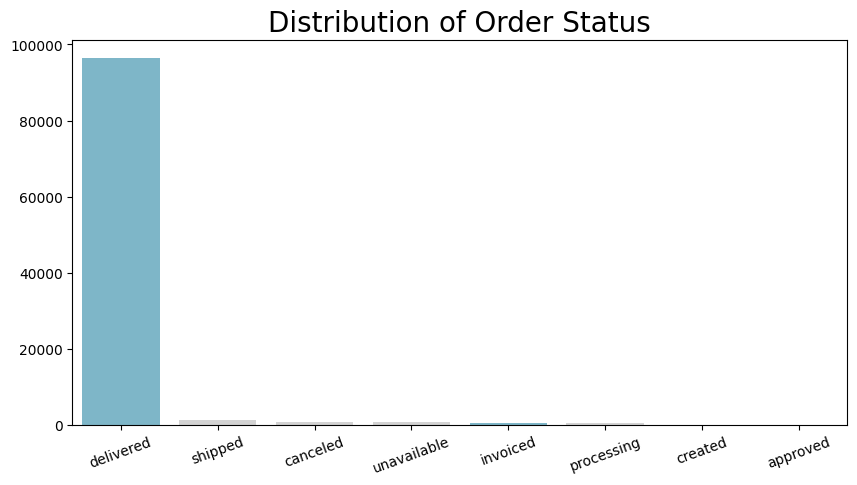

In [191]:
plt.figure(figsize=(10,5))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="order_status",
    y="order_count",
    data=order_status_df.sort_values(by="order_count", ascending=False),
    palette=colors
)

plt.title("Distribution of Order Status", loc="center", fontsize=20)

plt.ylabel(None)
plt.xlabel(None)

plt.xticks(rotation=20)
plt.show()

### Pertanyaan 2: Bagaimana performa waktu pengiriman pesanan, dan apakah terdapat keterlambatan pengiriman?

In [192]:
delivery_performance_df = df_orders[['delivery_time', 'delivery_delay']]

delivery_performance_df.describe()

,delivery_time,delivery_delay
count,96476.000000,96476.000000
mean,12.094086,-11.876881
std,9.551746,10.183854
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


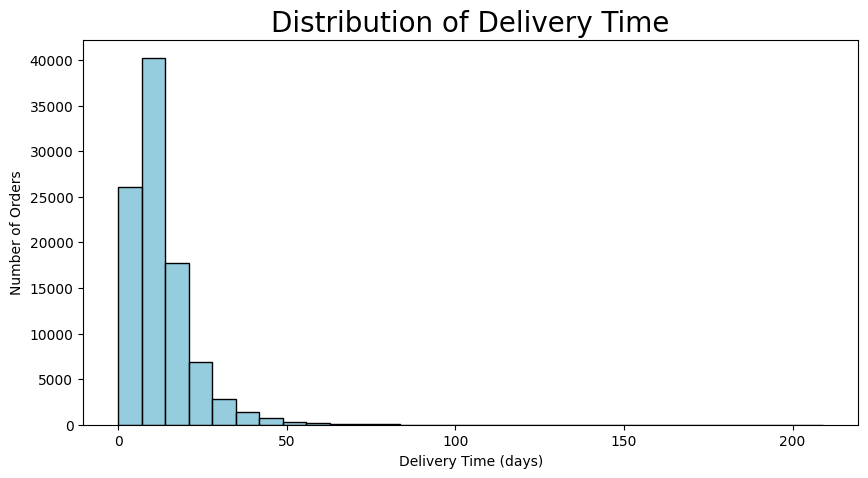

In [193]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_orders['delivery_time'],
    bins=30,
    color="#72BCD4"
)

plt.title("Distribution of Delivery Time", loc="center", fontsize=20)

plt.xlabel("Delivery Time (days)")
plt.ylabel("Number of Orders")

plt.show()

In [194]:
df_orders['delivery_status'] = df_orders['delivery_delay'].apply(
    lambda x: 'Delayed' if x > 0 else 'On Time'
)

In [195]:
delivery_status_df = df_orders.groupby(
    by='delivery_status'
).order_id.nunique().reset_index()

delivery_status_df.rename(columns={
    'order_id': 'order_count'
}, inplace=True)

delivery_status_df

,delivery_status,order_count
0,Delayed,6535
1,On Time,92906


/tmp/ipykernel_7027/403875112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


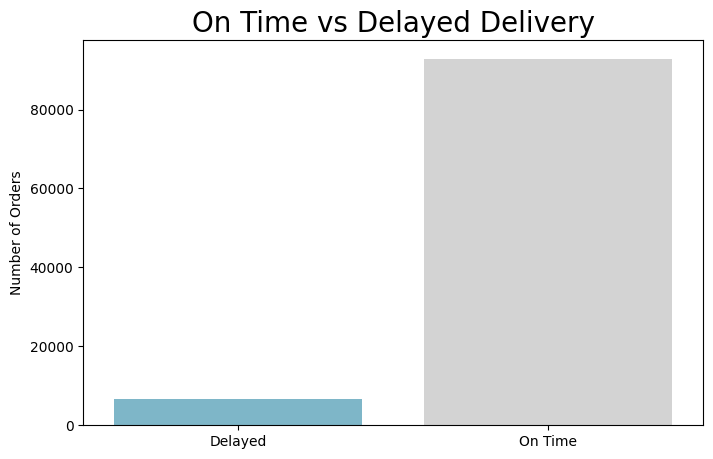

In [196]:
plt.figure(figsize=(8,5))

colors = ["#72BCD4", "#D3D3D3"]

sns.barplot(
    data=delivery_status_df,
    x='delivery_status',
    y='order_count',
    palette=colors
)

plt.title("On Time vs Delayed Delivery", loc="center", fontsize=20)

plt.xlabel(None)
plt.ylabel("Number of Orders")

plt.show()

### Pertanyaan 3: Apakah waktu pengiriman memengaruhi tingkat kepuasan pelanggan?

In [197]:
review_delivery_df = df_all.groupby(
    by='review_score'
).agg({
    'delivery_delay': 'mean'
}).reset_index()

review_delivery_df

,review_score,delivery_delay
0,1.0,-5.993827
1,2.0,-9.748141
2,3.0,-11.114301
3,4.0,-12.468533
4,5.0,-13.443437


/tmp/ipykernel_7027/70361219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


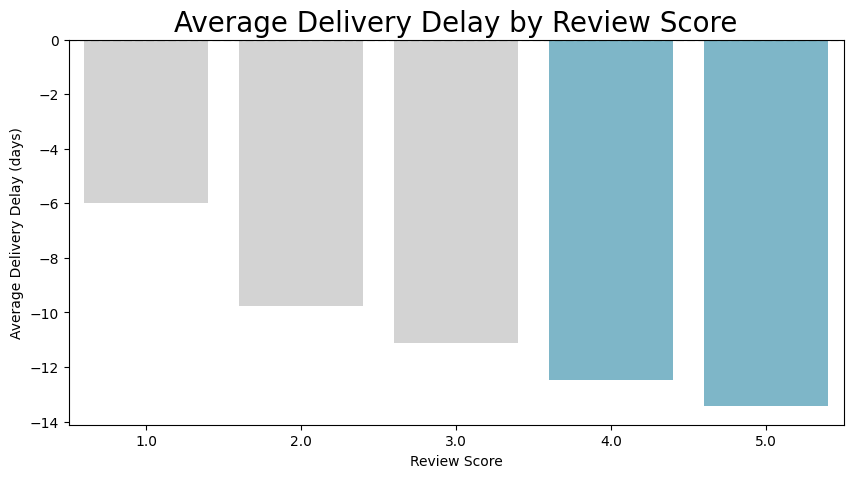

In [205]:
plt.figure(figsize=(10,5))

colors = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#72BCD4", "#72BCD4"]

sns.barplot(
    data=review_delivery_df,
    x='review_score',
    y='delivery_delay',
    palette=colors
)

plt.axhline(y=0, color='black', linestyle='--')

plt.title(
    "Average Delivery Delay by Review Score",
    loc="center",
    fontsize=20
)

plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (days)")

plt.show()

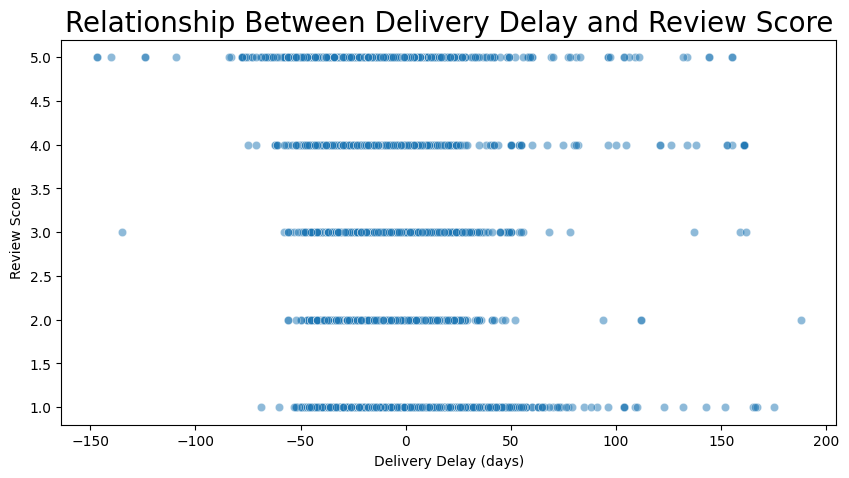

In [199]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_all,
    x='delivery_delay',
    y='review_score',
    alpha=0.5
)

plt.title(
    "Relationship Between Delivery Delay and Review Score",
    loc="center",
    fontsize=20
)

plt.xlabel("Delivery Delay (days)")
plt.ylabel("Review Score")

plt.show()

###Pertanyaan 4: Kategori produk apa yang paling banyak terjual dan menghasilkan revenue terbesar?

In [206]:
sum_order_items_df = df_all.groupby(
    by="product_category_name_english"
).agg({
    "order_item_id": "count"
}).sort_values(by="order_item_id", ascending=False).reset_index()

sum_order_items_df.rename(columns={
    "order_item_id": "total_sales"
}, inplace=True)

sum_order_items_df.head()

,product_category_name_english,total_sales
0,bed_bath_table,13697
1,health_beauty,10032
2,sports_leisure,9004
3,furniture_decor,8832
4,computers_accessories,8150


/tmp/ipykernel_7027/4173366356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7027/4173366356.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


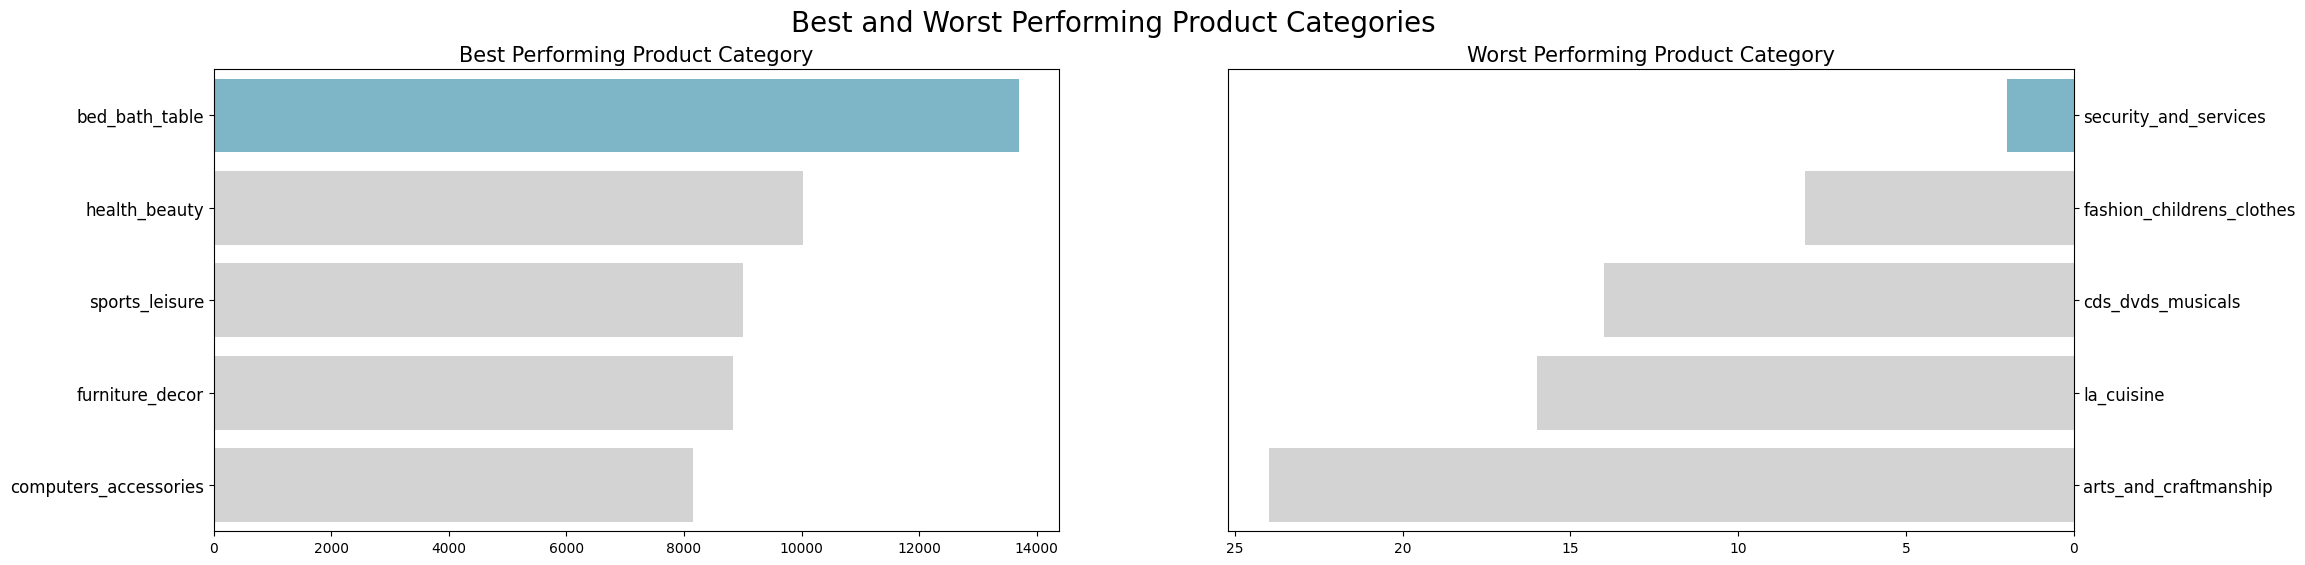

In [207]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24,6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="total_sales",
    y="product_category_name_english",
    data=sum_order_items_df.head(5),
    palette=colors,
    ax=ax[0]
)

ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product Category", loc="center", fontsize=15)
ax[0].tick_params(axis='y', labelsize=12)

sns.barplot(
    x="total_sales",
    y="product_category_name_english",
    data=sum_order_items_df.sort_values(by="total_sales", ascending=True).head(5),
    palette=colors,
    ax=ax[1]
)

ax[1].set_ylabel(None)
ax[1].set_xlabel(None)

ax[1].invert_xaxis()

ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

ax[1].set_title("Worst Performing Product Category", loc="center", fontsize=15)

ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle(
    "Best and Worst Performing Product Categories",
    fontsize=20
)

plt.show()

In [208]:
revenue_category_df = df_all.groupby(
    by="product_category_name_english"
).agg({
    "payment_value": "sum"
}).sort_values(by="payment_value", ascending=False).reset_index()

revenue_category_df.head()

,product_category_name_english,payment_value
0,bed_bath_table,1997726.12
1,health_beauty,1662963.59
2,computers_accessories,1599481.06
3,furniture_decor,1443963.61
4,watches_gifts,1430553.48


/tmp/ipykernel_7027/252496170.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


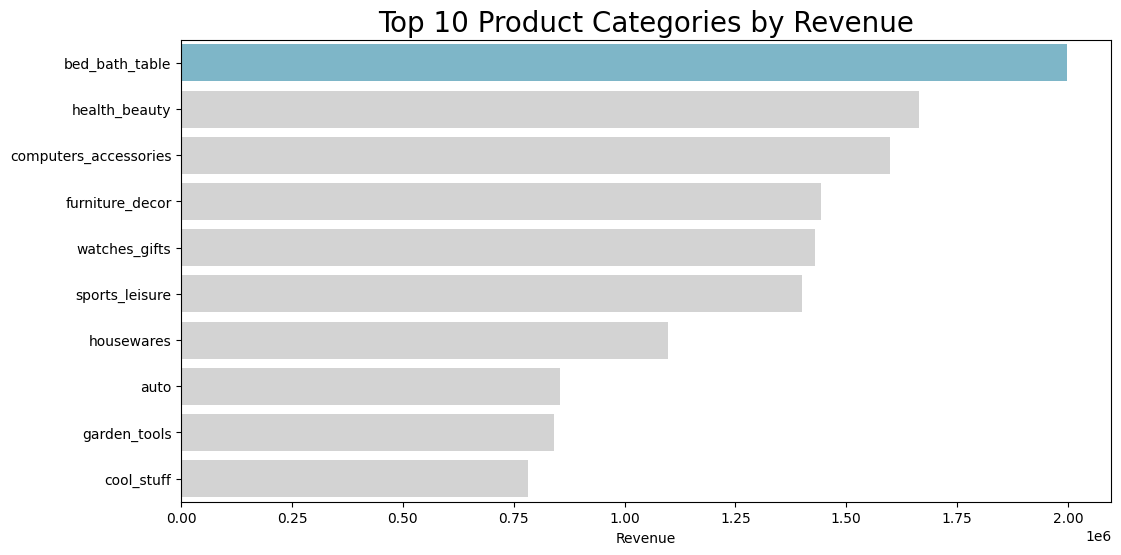

In [209]:
plt.figure(figsize=(12,6))

colors = ["#72BCD4"] + ["#D3D3D3"] * 9

sns.barplot(
    data=revenue_category_df.head(10),
    x="payment_value",
    y="product_category_name_english",
    palette=colors
)

plt.title(
    "Top 10 Product Categories by Revenue",
    loc="center",
    fontsize=20
)

plt.xlabel("Revenue")
plt.ylabel(None)

plt.show()

###Pertanyaan 5: Dari wilayah mana pelanggan paling banyak berasal, dan bagaimana distribusi order berdasarkan wilayah?

In [210]:
bystate_df = df_all.groupby(
    by="customer_state"
).customer_unique_id.nunique().reset_index()

bystate_df.rename(columns={
    "customer_unique_id": "customer_count"
}, inplace=True)

bystate_df.head()

,customer_state,customer_count
0,AC,77
1,AL,401
2,AM,143
3,AP,67
4,BA,3277


/tmp/ipykernel_7027/49936398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7027/49936398.py:5: UserWarning: The palette list has more values (21) than needed (10), which may not be intended.
  sns.barplot(


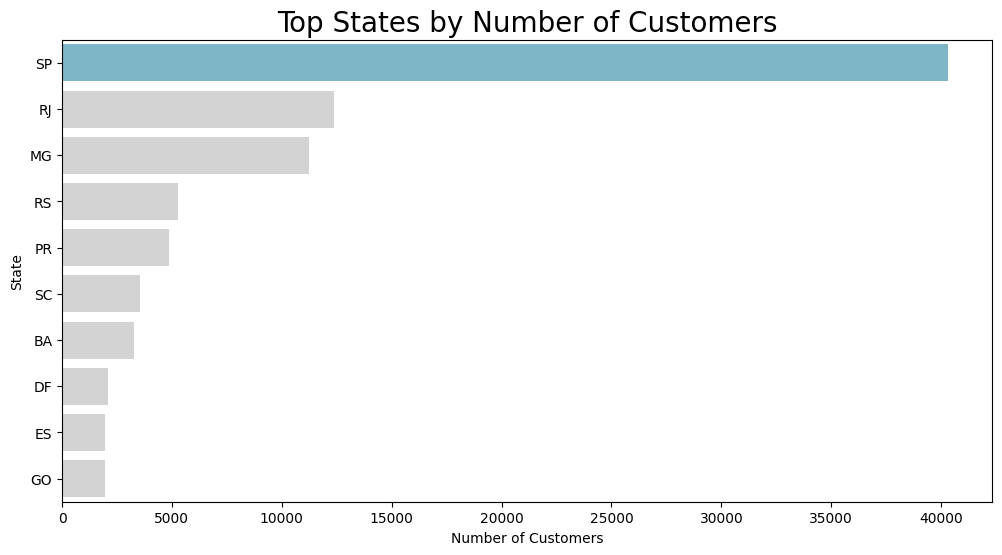

In [211]:
plt.figure(figsize=(12,6))

colors = ["#72BCD4"] + ["#D3D3D3"] * 20

sns.barplot(
    data=bystate_df.sort_values(by="customer_count", ascending=False).head(10),
    x="customer_count",
    y="customer_state",
    palette=colors
)

plt.title(
    "Top States by Number of Customers",
    loc="center",
    fontsize=20
)

plt.xlabel("Number of Customers")
plt.ylabel("State")

plt.show()

In [212]:
state_orders_df = df_all.groupby(
    by="customer_state"
).agg({
    "order_id": "nunique"
}).sort_values(by="order_id", ascending=False).reset_index()

state_orders_df.rename(columns={
    "order_id": "order_count"
}, inplace=True)

state_orders_df.head()

,customer_state,order_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045


/tmp/ipykernel_7027/3306902584.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7027/3306902584.py:5: UserWarning: The palette list has more values (21) than needed (10), which may not be intended.
  sns.barplot(


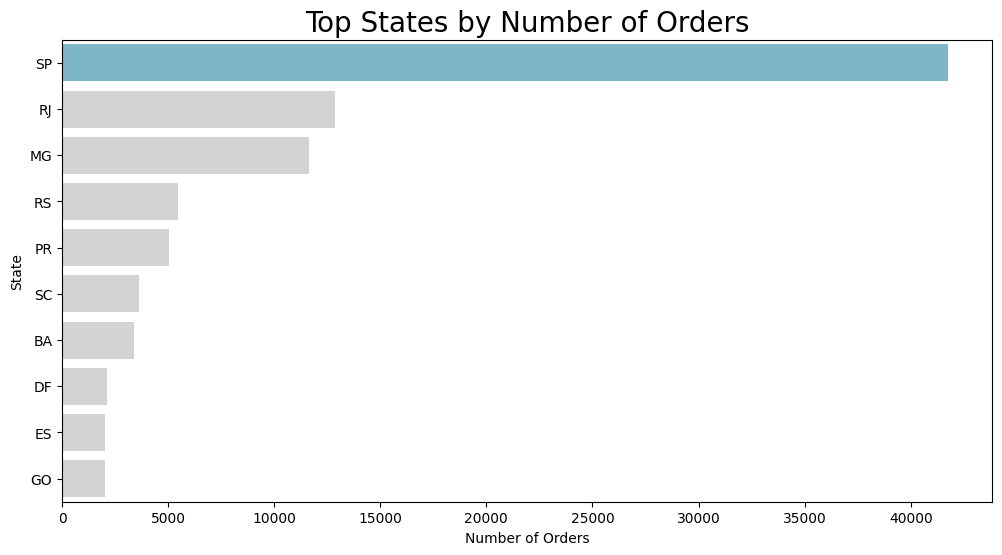

In [213]:
plt.figure(figsize=(12,6))

colors = ["#72BCD4"] + ["#D3D3D3"] * 20

sns.barplot(
    data=state_orders_df.head(10),
    x="order_count",
    y="customer_state",
    palette=colors
)

plt.title(
    "Top States by Number of Orders",
    loc="center",
    fontsize=20
)

plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.show()

##**Insight:**
###Pertanyaan 1:
Berdasarkan visualisasi yang telah dibuat, mayoritas order pada platform e-commerce berhasil diselesaikan dengan status delivered. Hal ini menunjukkan bahwa sebagian besar proses transaksi dan pengiriman berjalan dengan baik. Selain itu, jumlah order mengalami fluktuasi pada beberapa periode waktu tertentu yang mengindikasikan adanya perubahan aktivitas pembelian pelanggan dari waktu ke waktu.
###Pertanyaan 2:
Berdasarkan distribusi waktu pengiriman, sebagian besar pesanan berhasil dikirim dalam waktu yang relatif cepat. Namun, masih terdapat sejumlah pesanan yang mengalami keterlambatan pengiriman. Kondisi ini menunjukkan bahwa meskipun performa logistik sudah cukup baik, masih terdapat beberapa kendala pengiriman yang perlu diperhatikan untuk meningkatkan kualitas layanan.
###Pertanyaan 3:
Hasil visualisasi menunjukkan bahwa pelanggan dengan review score tinggi cenderung menerima pesanan lebih cepat atau tepat waktu dibandingkan pelanggan dengan review rendah. Hal ini mengindikasikan bahwa waktu pengiriman memiliki pengaruh terhadap tingkat kepuasan pelanggan pada platform e-commerce.
###Pertanyaan 4:
Berdasarkan visualisasi penjualan produk, terdapat beberapa kategori produk yang mendominasi jumlah transaksi dan revenue perusahaan. Hal ini menunjukkan bahwa minat pelanggan lebih terfokus pada kategori tertentu dibandingkan kategori lainnya. Kategori dengan revenue tertinggi juga menunjukkan kontribusi besar terhadap performa bisnis perusahaan secara keseluruhan.
###Pertanyaan 5:
Pelanggan berasal dari berbagai wilayah di Brazil dengan beberapa state mendominasi jumlah pelanggan dan order. Tingginya aktivitas transaksi pada wilayah tertentu menunjukkan bahwa area tersebut memiliki potensi pasar yang lebih besar dibandingkan wilayah lainnya.

In [220]:
df_all.to_csv("all_data.csv", index=False)

## Conclusion

Berdasarkan hasil Exploratory Data Analysis (EDA) dan visualisasi data pada dataset Olist e-commerce, diperoleh beberapa kesimpulan sebagai berikut:

1. Mayoritas order pada platform e-commerce berhasil diselesaikan dengan status delivered. Selain itu, jumlah order mengalami fluktuasi pada beberapa periode waktu tertentu yang menunjukkan perubahan aktivitas transaksi pelanggan dari waktu ke waktu.

2. Sebagian besar pesanan berhasil dikirim dalam waktu yang relatif cepat. Namun, masih terdapat sejumlah pengiriman yang mengalami keterlambatan sehingga performa logistik masih perlu ditingkatkan untuk menjaga kualitas layanan.

3. Waktu pengiriman memiliki pengaruh terhadap tingkat kepuasan pelanggan. Pelanggan yang menerima pesanan tepat waktu atau lebih cepat cenderung memberikan review score yang lebih tinggi dibandingkan pelanggan yang mengalami keterlambatan pengiriman.

4. Beberapa kategori produk mendominasi jumlah penjualan dan revenue perusahaan. Hal ini menunjukkan bahwa minat pelanggan lebih terfokus pada kategori produk tertentu yang memberikan kontribusi besar terhadap performa bisnis.

5. Pelanggan dan aktivitas order berasal dari berbagai wilayah di Brazil, dengan beberapa state memiliki jumlah pelanggan dan transaksi yang lebih tinggi dibandingkan wilayah lainnya. Wilayah tersebut berpotensi menjadi pasar utama bagi platform e-commerce.